Анализ данных и обучение модели для предсказания целевой переменной `IC50`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from scipy.stats import burr, fisk, genextreme, shapiro, weibull_min
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [2]:
pd.set_option('display.max_columns', None)

# 1. Загрузка и подготовка данных

## Загрузка датасета

In [3]:
train = pd.read_csv('train.csv', sep=',')

In [4]:
train.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,4.024775,1.987598,2.937188,1.292489,2.101284,-0.67,1.789178e+03,8.907639,4.533756,2.386264,82.881829,9.636773,6.730817,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,11.761885,18.199101,12.132734,11.440240,12.483670,4.736863,17.449271,0.0,0.000000,0.000000,0.000000,29.867250,30.331835,0,0.000000,4.899910,5.687386,0.000000,11.761885,24.967341,4.736863,0.000000,0.000000,30.331835,0.000000,0.000000,0,12.47,0.000000,0.000000,0.0,0.000000,0.000000,24.967341,5.687386,0.000000,17.828252,29.165378,4.736863,5.466584,1.919608,2.247685,0.000000,1.247130,2.132289,10.398397,0.000000,1.588307,0.000000,0.400000,13,0,2,0,1,1,1,0,1,3,0,3,1,0,1,1,2,2.1714,57.0650,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.46

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


Выполним переименование колонок, чтобы упростить их дальнейшее использование:

In [6]:
train.rename(
    columns={
        'IC50, mM': 'IC50', 
        'CC50, mM': 'CC50' 
    }, 
    inplace=True
)

Удаляем лишние колонки (index - это не признак):

In [7]:
train = train.drop('index', axis=1)

## Пропуски

In [8]:
absences = train.isna().sum().sum()
absences_perc = absences / len(train) * 100
print(f"Количество пропусков: {absences} ({absences_perc:.2f}%)")

Количество пропусков: 24 (3.20%)


Удалим полностью пустые строки:

In [9]:
rows_with_missing = train[train.isnull().any(axis=1)]

In [10]:
train = train.dropna()

In [11]:
absences = train.isna().sum().sum()
absences_perc = absences / len(train) * 100
print(f"Количество пропусков после удаления: {absences} ({absences_perc:.2f}%)")

Количество пропусков после удаления: 0 (0.00%)


## Дубликаты

In [12]:
duplicates = train.duplicated().sum()
duplicates_perc = duplicates / len(train) * 100
print(f"Количество дубликатов: {duplicates} ({duplicates_perc:.2f}%)")

Количество дубликатов: 15 (2.00%)


Удалим выявленные дубликаты:

In [13]:
train.drop_duplicates(inplace=True)

In [14]:
duplicates = train.duplicated().sum()
duplicates_perc = duplicates / len(train) * 100
print(f"Количество дубликатов после удаления: {duplicates} ({duplicates_perc:.2f}%)")

Количество дубликатов после удаления: 0 (0.00%)


## Заключение

В рамках предварительной обработки датасета выполнены следующие шаги:
1. Загрузка данных  
    Загружен файл train.csv: 751 запись, 214 признаков (107 float64, 107 int64).

2. Предобработка колонок  
    * Переименованы целевые переменные: `IC50, mM` -> `IC50`, `CC50, mM` -> `CC50` для удобства работы.  
    * Удалён служебный столбец `index`, не являющийся признаком.

3. Работа с пропусками  
    * Обнаружено 24 пропущенных значения (3.20% от общего объёма).  
    * Строки с пропусками удалены — после очистки пропусков не осталось.

4. Устранение дубликатов  
    * Выявлено 15 полностью дублированных строк (2.00%).  
    * Дубликаты удалены для предотвращения смещения модели.

**Результат:** получен чистый датасет без пропусков и дубликатов, готовый к разведочному анализу и построению моделей.

# 2. Анализ данных

## Параметры датасета

Список колонок:

In [15]:
train.columns

Index(['IC50', 'CC50', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex',
       'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=213)

Параметры датасета:

In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 734 entries, 0 to 750
Columns: 213 entries, IC50 to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.2 MB


In [17]:
train.describe()

,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.0,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,7.340000e+02,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,7.340000e+02,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.0,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.0,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.

## Анализ целевой переменной

In [18]:
TARGET = 'IC50'

### Распределение

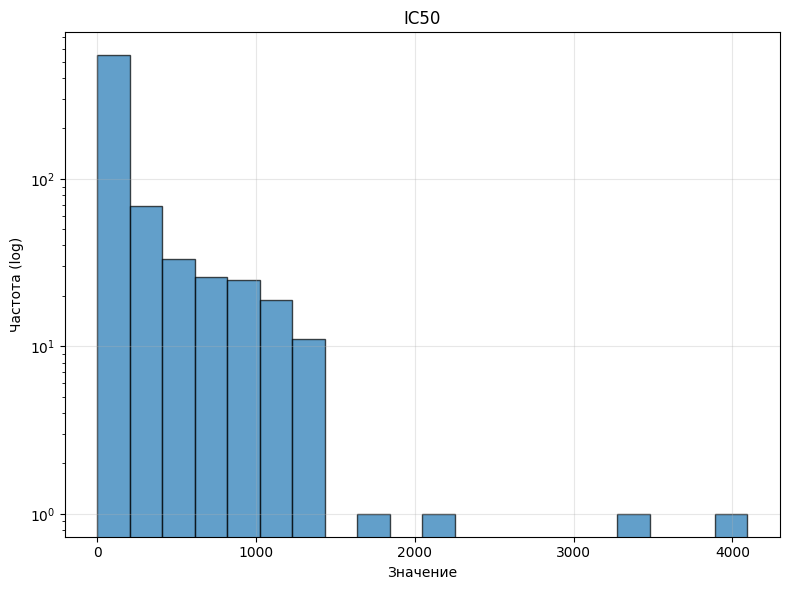

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
data = train[TARGET]
    
ax.hist(
    data, 
    bins=20, 
    alpha=0.7, 
    edgecolor='black'
)
ax.set_title(TARGET, fontsize=12)
ax.set_xlabel('Значение', fontsize=10)
ax.set_ylabel('Частота (log)', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

* Распределение является сильно асимметричным с правосторонним скосом. Основной массив данных сконцентрирован в левой части графика (низкие значения), а хвост распределения тянется далеко вправо.

* Мода распределения находится в первом интервале ~[0, 200). Высота этого столбца значительно превышает 10^2, визуально можно оценить частоту примерно в 500–600 единиц.

* Наблюдается экспоненциальный характер убывания частоты по мере роста значения.
    * Второй бин [200, 400) имеет частоту чуть ниже 10^2 (~70-80);
    * Третий бин [400-600) — около 30-40.
    * Далее частоты плавно снижаются до 10^1 в районе значения 1400.
* В правой части графика (значения > 1500) наблюдаются изолированные столбцы очень малой высоты.Высота этих столбцов соответствует ~1.

**Итог**: График демонстрирует совокупность данных, где подавляющее большинство значений (сотни случаев) сосредоточено в диапазоне от 0 до 1500, при этом существуют единичные аномально высокие значения, разбросанные вплоть до 4000.

### Распределение Вейбулла

In [20]:
train_clean = train.dropna()

In [21]:
data = train_clean[TARGET]

In [22]:
data_positive = data[data > 0]
data_positive

0      102.414420
1        0.044333
2        4.437964
3        6.827881
4        2.003253
          ...    
746    197.720728
747     25.669224
748      0.211002
749    208.368590
750    447.604806
Name: IC50, Length: 734, dtype: float64

Подбираем параметры распределения:

In [23]:
shape_weibull, loc_weibull, scale_weibull = stats.weibull_min.fit(data_positive, floc=0)

In [24]:
print(f"k={shape_weibull:.4f}")
print(f"loc={loc_weibull:.4f}")
print(f"λ={scale_weibull:.4f}")

k=0.5546
loc=0.0000
λ=119.4123


**k<1:** Это ключевая характеристика. При k<1 функция плотности вероятности (PDF) является монотонно убывающей.

**Значение λ=119.41**: Этот параметр определяет масштаб распределения. Около 63.2% данных должны лежать в интервале от 0 до λ (то есть до ~119)

Визуализация теоретической кривой Вейбулла:

#### Теоретическая кривая

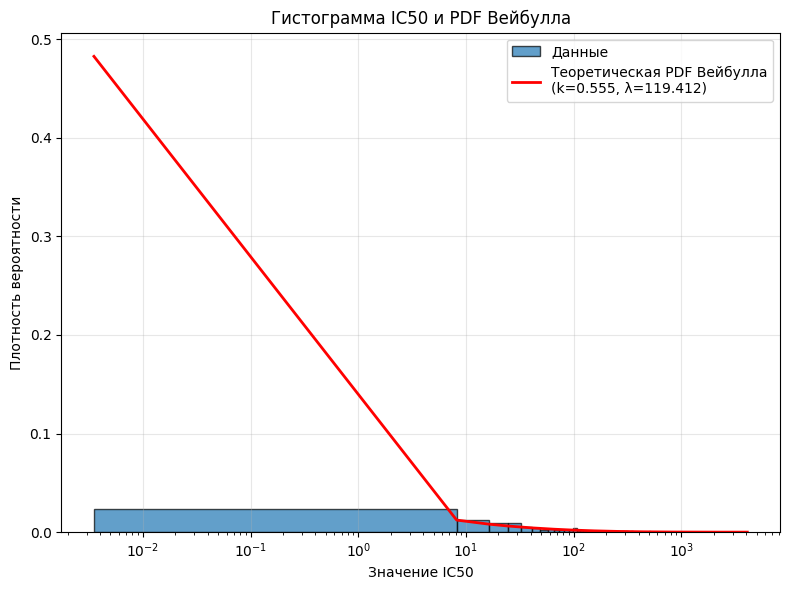

In [25]:
plt.figure(figsize=(8, 6))

count, bins, ignored = plt.hist(
    data_positive, 
    bins=500, 
    density=True,
    alpha=0.7,
    label="Данные",
    edgecolor='black'
)

pdf_weibull = stats.weibull_min.pdf(bins, shape_weibull, loc=loc_weibull, scale=scale_weibull)

plt.plot(
    bins, 
    pdf_weibull, 
    'r-', 
    linewidth=2,
    label=f'Теоретическая PDF Вейбулла\n(k={shape_weibull:.3f}, λ={scale_weibull:.3f})'
)

plt.xlabel('Значение IC50')
plt.ylabel('Плотность вероятности')
plt.title('Гистограмма IC50 и PDF Вейбулла')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

**Анализ данных**

* Основная масса данных сосредоточена в диапазоне от приблизительно 0.005 до 8.
* Распределение выглядит практически равномерным в указанном диапазоне. Высота столбцов составляет примерно 0.025.
* После значения 10^1 видны очень низкие остатки столбцов, уходящие вправо, но их высота близка к нулю.

**Анализ теоретической модели**

* Кривая начинается с высокого значения плотности вероятности (около 0.48) при малых значениях x(около 10^−2).
* Затем кривая монотонно убывает. На графике спад выглядит почти линейным, что характерно для степенной зависимости при определенных условиях.
* В районе значения X≈10^1 происходит резкий излом, после чего кривая резко падает до значений, близких к нулю, и формирует длинный «вост вправо до 10^3.

**Сравнение модели и данных**

Наблюдается значительное визуальное расхождение между теоретической моделью (красная линия) и реальными данными (синие столбцы).

* Теоретическая кривая предсказывает гораздо более высокую плотность вероятности в области малых значений (от 0.01 до 1), чем показывают данные. Модель начинается с 0.48, а данные держатся на уровне 0.025
* Данные имеют форму, близкую к равномерной (горизонтальный плато), тогда как модель имеет резко убывающий характер.
* Модель и данные визуально сближаются только в областипримерно при x=10, где и теоретическая кривая падает, и основная масса данных заканчивается.

**Вывод**
График демонстрирует попытку аппроксимации эмпирического распределения (синее) теоретическим распределением Вейбулла (красное). Визуально подгонка выглядит неудачной: теоретическая кривая не описывает плоский характер распределения данных в основном рабочем диапазоне и значительно завышает плотность вероятности для малых значений.

#### Q‑Q график

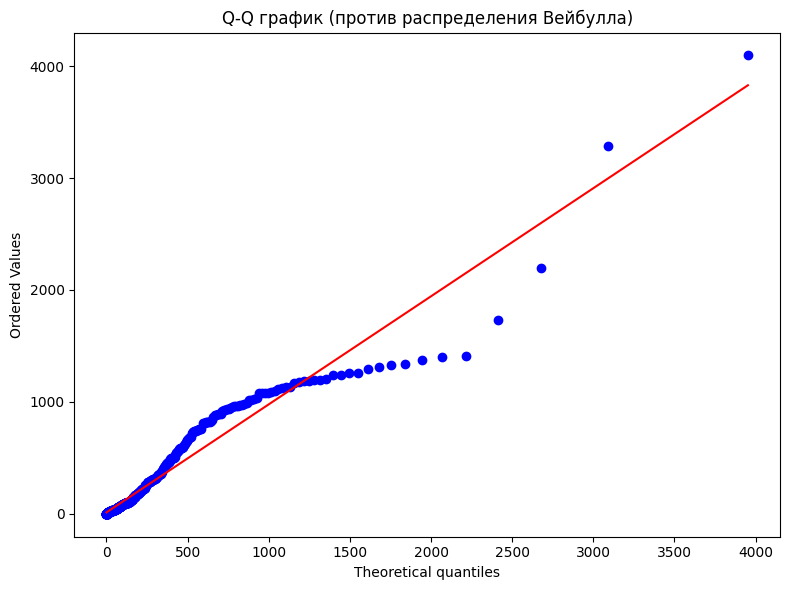

In [26]:
plt.figure(figsize=(8, 6))

weibull_dist = stats.weibull_min(shape_weibull, loc=loc_weibull, scale=scale_weibull)
stats.probplot(
    data_positive, 
    dist=weibull_dist, 
    plot=plt
)
plt.title('Q‑Q график (против распределения Вейбулла)')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

График можно разделить на несколько характерных зон:

* Начальный участок (X от 0 до ~500):

        Точки плотно прилегают к красной линии.
        В области малых значений (нижний хвост распределения) эмпирические данные хорошо согласуются с теоретическим распределением Вейбулла.

* Участок отклонения (X от ~500 до ~1200):

        Точки начинают отклоняться вверх от красной линии, образуя дугу.
        Реальные данные становятся выше, чем предсказывает модель (X).
        В этом диапазоне реальные значения «тяжелее» или больше, чем ожидалось бы по модели Вейбулла.

* Участок «плато» (X от ~1200 до ~2200):

        Наблюдается резкое изменение характера графика. Точки выстраиваются почти в горизонтальную линию.
        Реальные данные колеблются в узком диапазоне, в то время как теоретические квантили (X) продолжают расти до 2200.
        ВЭто указывает на значительное расхождение. В выборке есть большая группа значений, которые очень близки друг к другу, тогда как теоретическая модель ожидает их большего разброса в этом диапазоне.

* Верхний хвост (X > 2200):

        После участка «плато» точки резко уходят вверх и вправо, отрываясь от основной массы.
        Видны отдельные точки с координатами примерно (2500, 1700), (2700, 2200), (3100, 3300) и одна крайняя точка около (4000, 4100).
        Наличие тяжелых выбросов  в правой части распределения. Эти значения значительно превышают ожидания теоретической модели для соответствующих квантилей.

#### Тест Колмогорова-Смирнова

In [27]:
ks_stat_weibull, ks_pvalue_weibull = stats.kstest(
    data_positive,
    lambda x: stats.weibull_min.cdf(x, shape_weibull, loc=loc_weibull, scale=scale_weibull)
)

In [28]:
print(f"Статистика: {ks_stat_weibull:.4f}")
print(f"p‑значение: {ks_pvalue_weibull:.4f}")

Статистика: 0.0653
p‑значение: 0.0037


p-значение < 0.05, что говорит о том, что данные не согласуются с распределением Вейбулла

#### Заключение

Соответствие данных распределению Вейбулла низкое.

Хотя начало распределения (малые значения) описывается хорошо, основная масса данных (середина и конец) демонстрирует систематические отклонения.

Форма графика — сначала выпуклость вверх, затем плато, а после — резкий скачок — указывает на то, что реальное распределение данных, вероятно, не является чистым распределением Вейбулла. Оно может быть мультимодальным (иметь несколько пиков) или обладать значительно более «тяжёлым» хвостом, чем предполагает данная параметрическая модель.

Проверка по тесту Колмогорова–Смирнова также показала, что данные не согласуются с распределением.

**Рекомендации для обучения модели**

Учитывая выявленную сильную асимметрию (skewness) и наличие выбросов, стандартные подходы регрессии будут неэффективны. 

Для обучения модели следует использовать алгоритмы Random Forest, XGBoost, LightGBM и им подобные. 

### Анализ выбросов

#### Визуализация

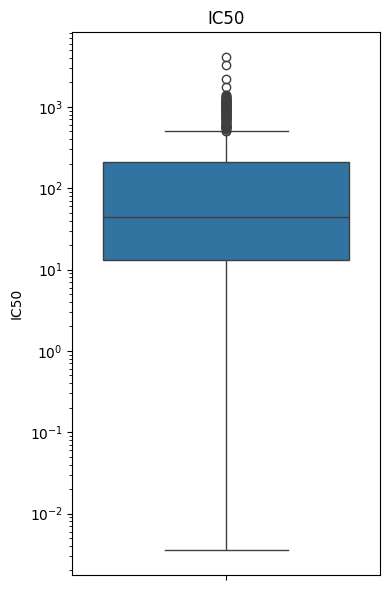

In [29]:
fig, axes = plt.subplots(figsize=(4, 6))
sns.boxplot(
    y=train[TARGET], 
    ax=axes
)
axes.set_title(TARGET)
axes.set_yscale('log')
plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

График показывает распределение данных с очень высокой дисперсией и правосторонней асимметрией.

Большинство данных (50%) сосредоточено в диапазоне от ~15 до ~250.

Медиана составляет около 50.

Существует значительное количество значений, близких к нулю (нижний ус до 10:−2).
Существует группа экстремальных значений (выбросов) в области больших чисел (тысячи), которые выходят за пределы ожидаемого статистического размаха.

#### Удаление выбросов

Применим IQR для удаления выбросов

In [30]:
Q1 = data_positive.quantile(0.25)
Q3 = data_positive.quantile(0.75)

In [31]:
print(f"Q1={Q1:.4f}")
print(f"Q3={Q3:.4f}")

Q1=12.9800
Q3=208.8379


In [32]:
IQR = Q3 - Q1

In [33]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [34]:
print(f"Нижняя граница нормальных значений: {lower_bound:.4f}")
print(f"Верхняя граница нормальных значений: {upper_bound:.4f}")

Нижняя граница нормальных значений: -280.8068
Верхняя граница нормальных значений: 502.6247


In [35]:
mask = (train[TARGET] >= lower_bound) & (train[TARGET] <= upper_bound) & (train[TARGET] > 0)

In [36]:
filtered_data = train_clean[mask].copy()

In [37]:
print(f"Исходное количество: {len(data_positive)}")
print(f"После удаления выбросов: {len(filtered_data)}")

Исходное количество: 734
После удаления выбросов: 634


### Повторная проверка на распределение Вейбулла

#### Тест Колмогорова-Смирнова

In [38]:
test_target = filtered_data[TARGET].dropna()

In [39]:
shape_filtered, loc_filtered, scale_filtered = weibull_min.fit(test_target, floc=0)

In [40]:
ks_stat_filtered, ks_pvalue_filtered = stats.kstest(
    test_target,
    lambda x: weibull_min.cdf(x, shape_filtered, loc=loc_filtered, scale=scale_filtered)
)

In [41]:
print(f"Статистика: {ks_stat_filtered:.4f}")
print(f"p‑значение: {ks_pvalue_filtered:.4f}")

Статистика: 0.0412
p‑значение: 0.2258


p-значение > 0.05, что говорит о том, что данные после удаления выбросов согласуются с распределением Вейбулла.

#### Подбор параметров на отфильтрованных данных

In [42]:
data = train_clean[TARGET].dropna()
data = data[(data > 0) & (data >= lower_bound) & (data <= upper_bound)]

In [43]:
shape_final, loc_final, scale_final = weibull_min.fit(data, floc=0)

In [44]:
print(f"k={shape_final:.4f}")
print(f"loc={loc_final:.4f}")
print(f"λ={scale_final:.4f}")

k=0.6780
loc=0.0000
λ=63.7770


#### Теоретическая кривая

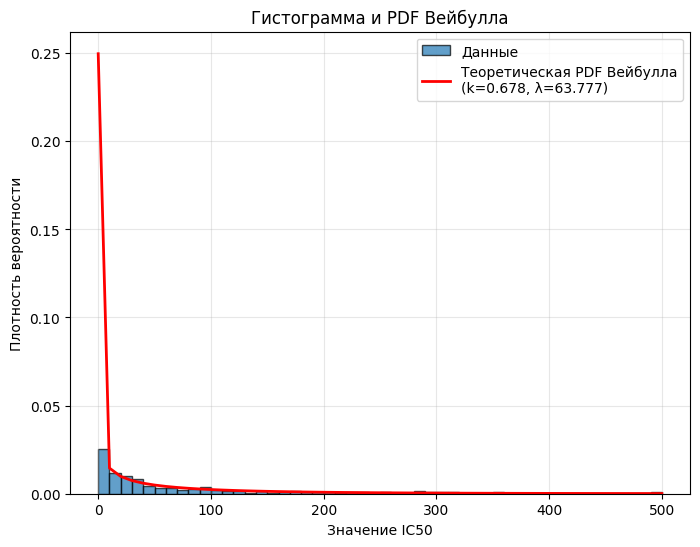

In [45]:
plt.figure(figsize=(8, 6))

count, bins, ignored = plt.hist(
    data, 
    bins=50, 
    density=True,
    alpha=0.7, 
    edgecolor='black',
    label='Данные'
)

pdf_weibull = weibull_min.pdf(bins, shape_final, loc=loc_final, scale=scale_final)

plt.plot(
    bins, 
    pdf_weibull, 
    'r-', 
    linewidth=2,
    label=f'Теоретическая PDF Вейбулла\n(k={shape_final:.3f}, λ={scale_final:.3f})'
)

plt.xlabel('Значение IC50')
plt.ylabel('Плотность вероятности')
plt.title('Гистограмма и PDF Вейбулла')
plt.legend()
plt.grid(True, alpha=0.3)

Удаление выбросов привело к следующим результатам:

* Модель стала описывать данные с характерным значением ~64 вместо ~119.
* Улучшение адекватности модели: Распределение Вейбулла стало лучше описывать данные, так как они не искажены редкими экстремальными значениями.
* Распределение стало чуть менее экстремальным (параметр k), хотя всё еще остается сильно скошенным вправо (k<1).

#### Q-Q график

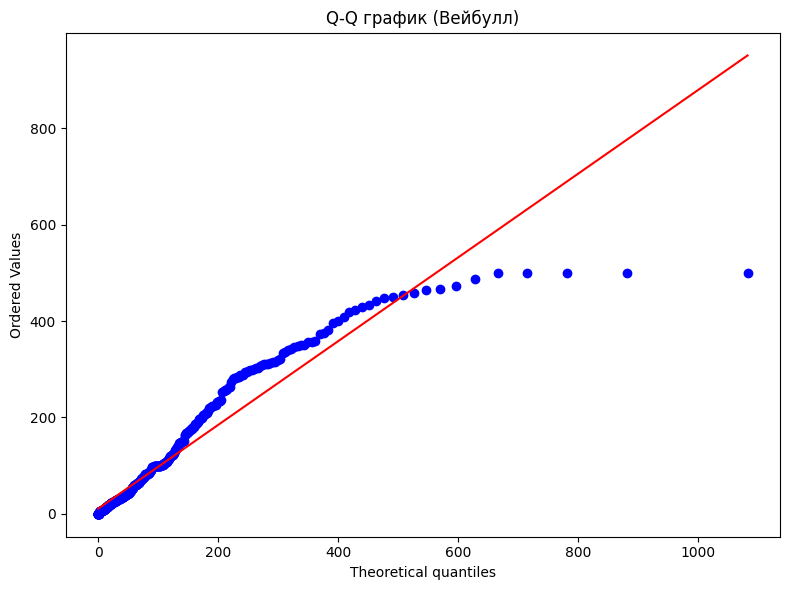

In [46]:
plt.figure(figsize=(8, 6))

stats.probplot(
    data, 
    dist=weibull_min(shape_final, loc=loc_final, scale=scale_final), 
    plot=plt
)
plt.title('Q‑Q график (Вейбулл)')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

* Точки хорошо ложатся на красную линию в нижней и средней части.
* В верхней части (правый хвост) наблюдается отклонение — точки выходят на плато, располагаясь ниже линии
* В целом хорошее соответствие распределению Вейбулла

**Итог**

Удаление выбросов существенно улучшило соответствие данных распределению Вейбулла.

#### CDF

In [47]:
sorted_data = np.sort(data)

In [48]:
y_empirical = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
y_theoretical = weibull_min.cdf(sorted_data, shape_final, loc=loc_final, scale=scale_final)

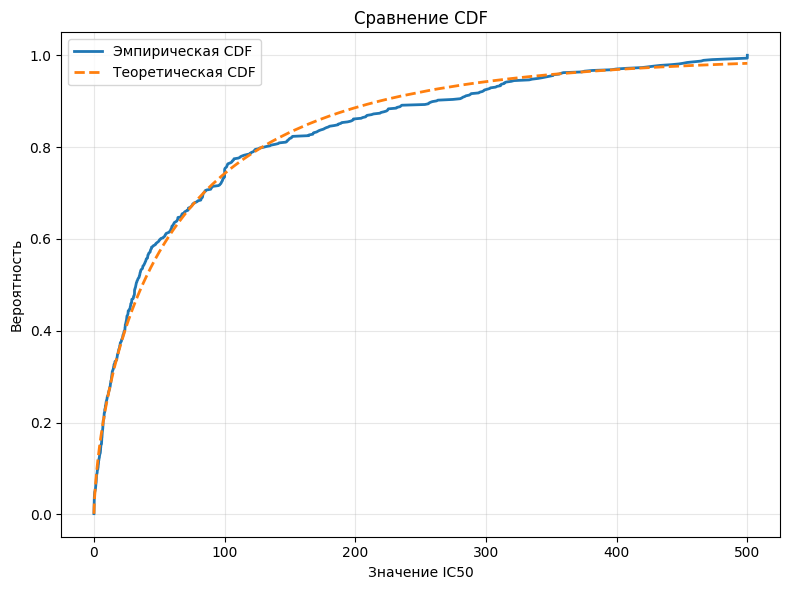

In [49]:
plt.figure(figsize=(8, 6))

plt.plot(
    sorted_data, 
    y_empirical, 
    label='Эмпирическая CDF', 
    linewidth=2
)
plt.plot(
    sorted_data, 
    y_theoretical, 
    label='Теоретическая CDF', 
    linewidth=2, 
    linestyle='--'
)
plt.xlabel('Значение IC50')
plt.ylabel('Вероятность')
plt.title('Сравнение CDF')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

В целом, график демонстрирует высокое соответствие модели реальным данным, но есть нюансы в разных диапазонах:

* Начальный участок (0 – 100):
  
        Наблюдается очень плотное совпадение линий. Обе кривые резко возрастают почти вертикально.
        Это говорит о том, что модель очень точно описывает основную массу данных, сосредоточенную в области низких значений.
        Синяя линия имеет характерные "ступеньки" (особенно заметные в районе 100), что типично для эмпирических данных конечной выборки. Оранжевая линия гладкая, как и положено теоретической функции.

* Средний участок (100 – 350):

    Появляется небольшое расхождение. Оранжевая линия проходит выше синей сплошной.
    Статистически это означает, что теоретическая модель предсказывает чуть большую вероятность накопления значений в этом диапазоне, чем наблюдается в реальности. То есть модель "думает", что данных в этом промежутке чуть больше (или они чуть меньше по значению), чем есть на самом деле.

* Конечный участок (350 – 500):

        Линии снова сближаются и пересекаются.
        В самом конце (около x = 500) синяя линия достигает вероятности 1.0 (или очень близко к ней), в то время как оранжевая линия все еще находится чуть ниже (около 0.98).
        Это указывает на то, что хвост теоретического распределения немного длиннее, чем у реальных данных. Модель предполагает наличие очень малой вероятности значений, превышающих 500, тогда как в эмпирических данных максимальное значение ограничено этой областью.

**Вывод**

График подтверждает, что выбранное теоретическое распределение (Вейбулла) является хорошей аппроксимацией для данного набора данных. Основные отклонения минимальны и наблюдаются преимущественно в хвосте распределения (правая часть графика).

### Определение статистического распределения

In [50]:
data_positive = filtered_data[TARGET].dropna()
data_positive = data_positive[data_positive > 0].values

In [51]:
distributions_to_test = [
    (genextreme, 'Обобщённое экстремальное'),
    (burr, 'Бурра'),
    (fisk, 'Лог-Логистическое')
]

In [52]:
for dist, name in distributions_to_test:
    params = dist.fit(data_positive)
    ks_stat, ks_pvalue = stats.kstest(data_positive, lambda x: dist.cdf(x, *params))
    print(f"{name}:")
    print(f"\tСтатистика KS: {ks_stat:.4f}")
    print(f"\tp‑значение: {ks_pvalue:.4f}")

Обобщённое экстремальное:
	Статистика KS: 0.0595
	p‑значение: 0.0215
Бурра:
	Статистика KS: 0.0462
	p‑значение: 0.1293
Лог-Логистическое:
	Статистика KS: 0.0672
	p‑значение: 0.0062


**Распределение Бурра (наилучшее)**

* Наименьшая KS-статистика (0.0462): наименьшее максимальное отклонение между эмпирической и теоретической CDF.
* p-значение 0.1293 > 0.05: нет оснований отвергать гипотезу о соответствии.
* Это распределение лучше всего описывает данные.

**Обобщённое экстремальное распределение**

* KS-статистика выше (0.0595).
* p-значение 0.0215 < 0.05: статистически значимое расхождение.
* Гипотеза отвергается на уровне значимости 5%.

**Лог-Логистическое распределение (наихудшее)**

* Наибольшая KS-статистика (0.0672): наибольшее отклонение.
* Наименьшее p-значение (0.0062): очень сильное расхождение.
* Гипотеза отвергается с высокой уверенностью.

### Тест Шапиро–Уилка на нормальность логарифмированных данных

In [53]:
log_data = np.log(data_positive)

In [54]:
stat_shapiro, p_value_shapiro = shapiro(log_data)

In [55]:
print(f"Статистика: {stat_shapiro:.4f}")
print(f"p‑значение: {p_value_shapiro:.4f}")

Статистика: 0.9252
p‑значение: 0.0000


p-значение < 0.05, что означает, что логарифмированные данные не согласуются с нормальным распределением.

## Заключение

**Ключевые выводы по анализу целевой переменной IC50**

* Целевая переменная IC50 демонстрирует выраженную правостороннюю асимметрию с высокой концентрацией данных в диапазоне 0–500 и длинным тяжёлым хвостом до 4000+.
* Исходные данные не согласуются с распределением Вейбулла (p-value = 0.0037 по тесту Колмогорова-Смирнова).
* После фильтрации выбросов методом IQR (оставлено 634 из 734 наблюдений) согласованность с распределением Вейбулла улучшается (p-value = 0.2258).
* Наилучшую аппроксимацию среди протестированных распределений показывает распределение Бурра (KS-статистика = 0.0462, p-value = 0.1293), что указывает на сложную, не унимодальную природу данных.
* Логарифмическая трансформация не приводит данные к нормальности (Шапиро-Уилк: p-value = 0.0000), что ограничивает применимость методов, требующих нормальности остатков.
* Экстремальные значения (>500) составляют ~14% выборки и существенно искажают параметры распределения.

**Рекомендуемые алгоритмы для обучения модели**

* Градиентный бустинг: LightGBM, XGBoost, CatBoost — устойчивы к асимметрии, не требуют нормализации признаков, поддерживают кастомные функции потерь.
* Ансамбли на основе деревьев: RandomForest, ExtraTrees — хороши как бейзлайн, менее склонны к переобучению на малых выборках.

# Обучение

## Формирование датасета признаков

In [56]:
df = filtered_data.copy()

In [57]:
exclude_cols = ['CC50', 'SI']

In [58]:
feature_cols = [
    col for col in df.columns 
    if col not in [TARGET] + exclude_cols
]

In [59]:
X = df[feature_cols].copy()
y = df[TARGET].copy()

In [60]:
X.fillna(X.mean(numeric_only=True), inplace=True)

In [61]:
print(f"Количество признаков: {X.shape[1]}")

Количество признаков: 210


## Стандартизация признаков

In [62]:
scaler = StandardScaler()

In [63]:
X_scaled = scaler.fit_transform(X)

## Подбор оптимального количества признаков

In [64]:
pca_full = PCA()

In [65]:
pca_full.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


**Визуализация объясненной дисперсии**

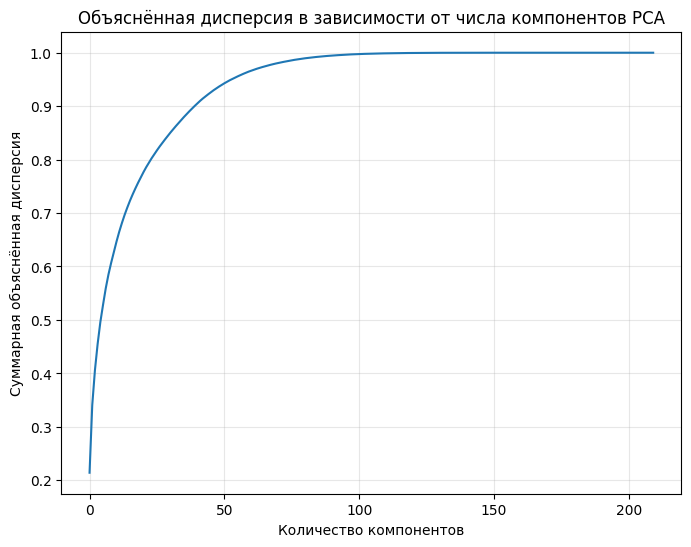

In [66]:
plt.figure(figsize=(8, 6))

plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Количество компонентов')
plt.ylabel('Суммарная объяснённая дисперсия')
plt.title('Объяснённая дисперсия в зависимости от числа компонентов PCA')
plt.grid(True, alpha=0.3)

plt.show()

<u>**Основные наблюдения**</u>

* Крутой подъём в начале (0-20 компонент): первые главные компоненты объясняют большую часть дисперсии. Многие признаки коррелируют друг с другом (избыточность информации).
* Замедление роста после ~30-40 компонент.
* Плато начинается после ~50 компонент (кривая выходит на ~95-98% дисперсии).
* Полное насыщение после ~100 компонент (100% дисперсии).

**Выбираем количество компонентов, объясняющих 95% дисперсии**

In [67]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

In [68]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

In [69]:
print(f"Оптимальное количество компонентов (95% дисперсии): {n_components}")

Оптимальное количество компонентов (95% дисперсии): 54


In [70]:
pca = PCA(n_components=n_components)

In [71]:
X_pca = pca.fit_transform(X_scaled)

In [72]:
print(f"Размерность после PCA: {X_pca.shape[1]} признаков")

Размерность после PCA: 54 признаков


### Разделение данных на обучающую и тестовую выборки

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, 
    y, 
    test_size=0.2, 
    random_state=42
)

### Подбор модели

In [74]:
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {
            'fit_intercept': [True, False],
            'positive': [True, False]
        }
    },

    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [300, 500, 800],
            'max_depth': [20, 30, None],
            'min_samples_split': [5, 10, 20],
            'min_samples_leaf': [2, 4, 8],
            'max_features': ['sqrt', 'log2', 0.5],
            'bootstrap': [True]
        }
    },
    
    'SVR': {
        'model': SVR(),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear']
        }
    }
}

Поиск лучшей модели:

In [75]:
best_model = None
best_score = float('inf')
best_name = ''

In [76]:
results = {}

In [77]:
for name, config in models.items():
    print(f"Подбор параметров для {name}...")
    
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    results[name] = {
        'best_params': grid_search.best_params_,
        'best_score': -grid_search.best_score_
    }
    
    print(f"\t{name}: RMSE = {-grid_search.best_score_:.4f}")
    
    if -grid_search.best_score_ < best_score:
        best_score = -grid_search.best_score_
        best_model = grid_search.best_estimator_
        best_name = name

Подбор параметров для Linear Regression...
	Linear Regression: RMSE = 119.3288
Подбор параметров для Random Forest...
	Random Forest: RMSE = 103.6051
Подбор параметров для SVR...
	SVR: RMSE = 110.8898


In [78]:
print(f"Лучшая модель: {best_name} с RMSE = {best_score:.4f}")

Лучшая модель: Random Forest с RMSE = 103.6051


### Предсказание на тестовой выборке

In [79]:
y_pred = best_model.predict(X_test)

In [80]:
test_rmse = root_mean_squared_error(y_test, y_pred)

In [81]:
print(f"RMSE на тестовой выборке: {test_rmse:.4f}")

RMSE на тестовой выборке: 108.9429


Сравнение с базовым подходом:

In [82]:
baseline_rmse = root_mean_squared_error(y_test, [y_train.mean()] * len(y_test))

In [83]:
print(f"Базовый RMSE (предсказание средним): {baseline_rmse:.4f}")
print(f"Улучшение относительно базового: {baseline_rmse - test_rmse:.4f}")

Базовый RMSE (предсказание средним): 118.9616
Улучшение относительно базового: 10.0187


# Тестирование

## Загрузка тестового датасета

In [84]:
test_df = pd.read_csv('test.csv', index_col=[0])

In [85]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Columns: 210 entries, MaxAbsEStateIndex to fr_urea
dtypes: float64(104), int64(106)
memory usage: 412.1 KB


## Подготовка датасета

### Индексы для итогового датасета

In [86]:
test_index = test_df.index.to_frame(name='index')

In [87]:
test_index.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   index   250 non-null    int64
dtypes: int64(1)
memory usage: 3.9 KB


### Признаки

In [88]:
X_test = test_df.copy()

In [89]:
print(f"Количество признаков в тестовом датасете: {X_test.shape[1]}")

Количество признаков в тестовом датасете: 210


### Пропуски

In [90]:
total_nan = X_test.isna().sum().sum()
print(f"Всего пропусков: {total_nan}")

Всего пропусков: 12


Заполняем пропуски средним значением:

In [91]:
X_test.fillna(X_test.mean(numeric_only=True), inplace=True)

### Стандартизация

In [92]:
X_test_scaled = scaler.transform(X_test)

### PCA

In [93]:
X_test_pca = pca.transform(X_test_scaled)
print(f"Размерность после PCA: {X_test_pca.shape[1]} признаков")

Размерность после PCA: 54 признаков


Размерность тестового датасета соответствует размерности обучающего датасета

## Предсказание

In [94]:
y_pred = best_model.predict(X_test_pca)

# Сохранение результатов

In [95]:
result_df = pd.DataFrame({
    'index': test_index['index'],
    'IC50': y_pred
})

In [96]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   250 non-null    int64  
 1   IC50    250 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 5.9 KB


In [97]:
result_df.head()

,index,IC50
index,,
0,0,76.012090
1,1,70.091237
2,2,52.781128
3,3,143.733846
4,4,142.907956


In [98]:
result_df.to_csv('predictions_ic50_2_improve_random_forest.csv', index=False)